In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [57]:
np.random.seed(42)
n = 1000
messy_data=pd.DataFrame({
    'id' : range(1000,1000 + n),
    'age':np.random.choice([np.nan,25,30,35,40,45,50],
                           size=n,p=[0.05,0.15,0.2,0.2,0.15,0.15,0.1]),
    "income": np.random.normal(50000,15000,n).round(-2),
    "gender": np.random.choice(['M','F','Male','Female','male',np.nan],n),
    "education": np.random.choice(["HS", "BA","MA", "PHD", "HIGH SCHOOL","BACHELOR's", np.nan],n),
    "state": np.random.choice(["CA","NY","TX","FL","IL","CALIFORNIA","NEWYORK", "TX", np.nan],n),
    "purchase_date": pd.date_range("2023-01-01", periods=n, freq='D').strftime('%Y-%m-%d'),
    "score": np.random.uniform(0,100,n).round(1)
})
#Introduce some duplicates
messy_data=pd.concat([messy_data,messy_data.iloc[[10,100,500]]])
messy_data= messy_data.reset_index(drop=True)
print("Shape of messy Data set :",messy_data.shape)
print("\nFirst Few rows:")
print(messy_data.head())
print("\nData info:")
print(messy_data.info())

Shape of messy Data set : (1003, 8)

First Few rows:
     id   age   income gender education    state purchase_date  score
0  1000  30.0  52700.0      M        HS       TX    2023-01-01    1.7
1  1001  50.0  30000.0      M       PHD       NY    2023-01-02   19.5
2  1002  40.0  55700.0   male       PHD       NY    2023-01-03   81.0
3  1003  35.0  59200.0   male       nan  NEWYORK    2023-01-04   27.3
4  1004  25.0  58400.0      M        HS       NY    2023-01-05   73.2

Data info:
<class 'pandas.DataFrame'>
RangeIndex: 1003 entries, 0 to 1002
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             1003 non-null   int64  
 1   age            947 non-null    float64
 2   income         1003 non-null   float64
 3   gender         1003 non-null   str    
 4   education      1003 non-null   str    
 5   state          1003 non-null   str    
 6   purchase_date  1003 non-null   str    
 7   score          1003

In [58]:
messy_data.describe(include="all")

,id,age,income,gender,education,state,purchase_date,score
count,1003.000000,947.000000,1003.000000,1003,1003,1003,1003,1003.000000
unique,NaN,NaN,NaN,6,7,8,1000,NaN
top,NaN,NaN,NaN,male,MA,TX,2023-01-11,NaN
freq,NaN,NaN,NaN,183,161,222,2,NaN
mean,1498.614158,36.019007,51524.825523,NaN,NaN,NaN,NaN,48.861316
std,289.075327,8.059088,14855.846643,NaN,NaN,NaN,NaN,28.634866
min,1000.000000,25.000000,6200.000000,NaN,NaN,NaN,NaN,0.100000
25%,1248.500000,30.000000,41550.000000,NaN,NaN,NaN,NaN,24.300000
50%,1499.000000,35.000000,51300.000000,NaN,NaN,NaN,NaN,48.500000
75%,1748.500000,45.000000,61100.000000,NaN,NaN,NaN,NaN,73.800000


In [59]:
messy_data.isnull().sum()

id                0
age              56
income            0
gender            0
education         0
state             0
purchase_date     0
score             0
dtype: int64

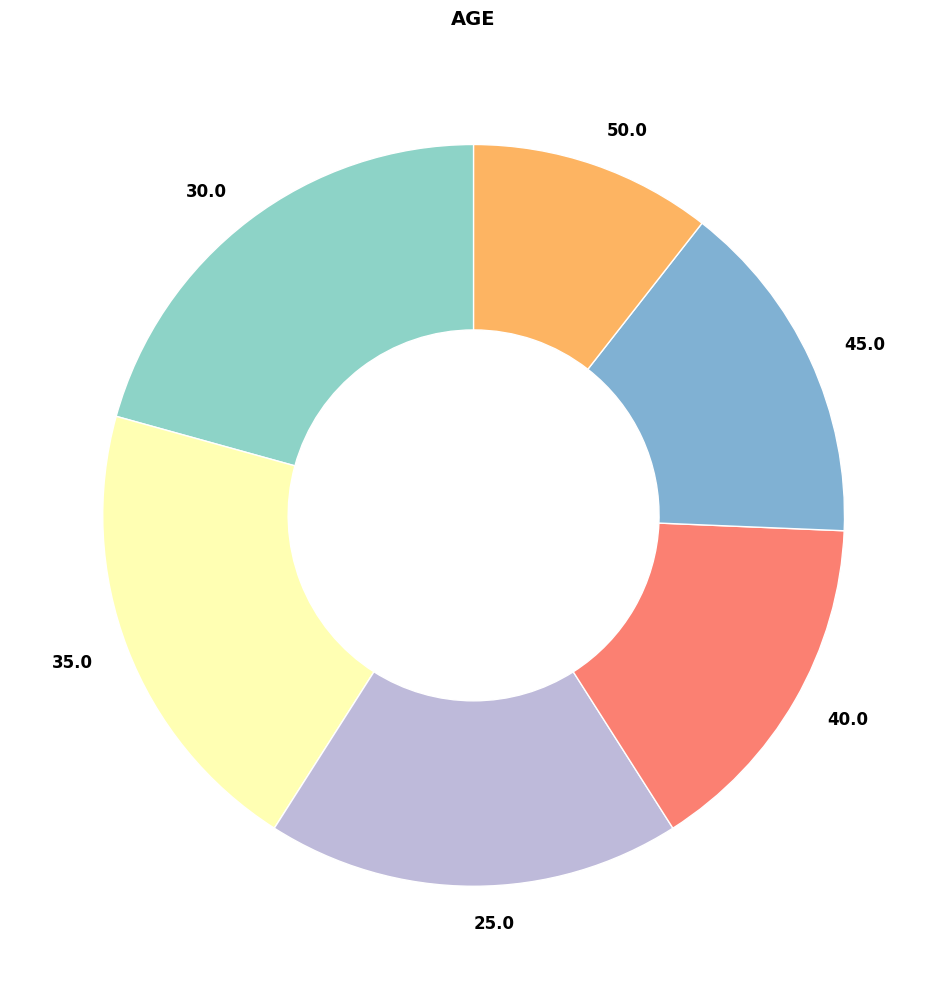

In [60]:
# FEATURE 3: FUEL TYPE - Proportions
plt.figure(figsize=(10, 10))
aa = messy_data['age'].value_counts()
top_5 = aa.head(60)
others = aa.iloc[60:].sum() if len(aa) > 60 else 0
if others > 0:
    top_5['Others'] = others

colors = sb.color_palette("Set3", len(top_5))
plt.pie(top_5, 
        labels=top_5.index, 
        colors=colors,
        startangle=90,
        wedgeprops=dict(width=0.5, edgecolor='white'),
        textprops={'fontsize': 12, 'color': 'black', 'weight': 'bold'})  # Control label color here!

plt.title('AGE', fontsize=14, fontweight='bold', pad=20)
centre_circle = plt.Circle((0,0), 0.3, fc='white')
plt.gca().add_artist(centre_circle)
plt.tight_layout()
plt.show()

In [61]:
aa = messy_data['age'].value_counts()

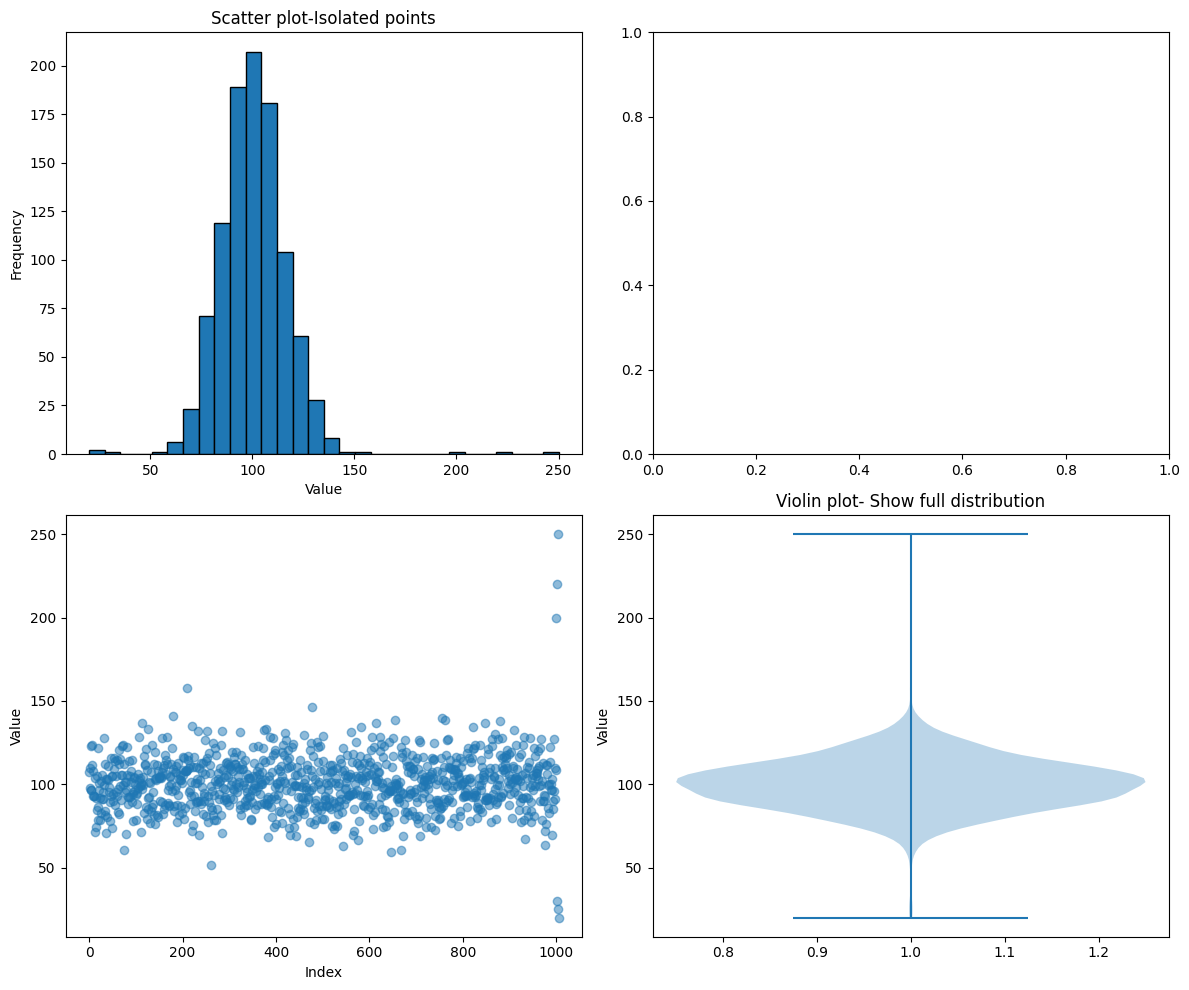

In [67]:
# Generate data with outlier 
np.random.seed(42)
normal_data=np.random.normal(100,15,1000)
outliers=np.array([200,220,30,25,250,20])
data_with_outliers=np.concatenate([normal_data,outliers])
df_outlier=pd.DataFrame({"value":data_with_outliers})
#Visual Methods 
fig,axes=plt.subplots(2,2, figsize=(12,10))
#Histograms
axes[0,0].hist(df_outlier["value"],bins=30,edgecolor="black")
axes[0,0].set_title("Histogram-Outliers stretch the scale")
axes[0,0].set_xlabel("Value")
axes[0,0].set_ylabel("Frequency")

# Scatter plot(index vs value)
axes[1,0].scatter(range(len(df_outlier)),df_outlier["value"],alpha=0.5)
axes[0,0].set_title("Scatter plot-Isolated points")
axes[1,0].set_xlabel("Index")
axes[1,0].set_ylabel("Value")
#Violin plot
parts=axes[1,1].violinplot(df_outlier["value"])
axes[1,1].set_title("Violin plot- Show full distribution")
axes[1,1].set_ylabel("Value")
plt.tight_layout()
plt.show()

In [68]:
def detect_outlier_zscore(data,threshold=3):
    """
    Detect outlier using Z-score method
    Z= (x-mean)/std
    |z|> threshold indicate outlier 
    """
    mean =np.mean(data)
    std=np.std(data)
    z_scores=np.abs((data-mean)/std)
    outliers=data[z_scores>threshold]
    print(f"Z-SCORE METHOD (threshold={threshold})")
    print("="*50)
    print(f"Standard Derivation:{std:.2f}")
    print(f"Number of Outlier: {len(outliers)}")
    print(f"Percentage outliers: {len(outliers)/len(data)*100:.2f}%")
    if len(outliers)>0:
        print(f"Outlier value:{outliers[:10].tolist()}")
    return outliers,z_scores
outliers_z,z_scores= detect_outlier_zscore(data_with_outliers)

Z-SCORE METHOD (threshold=3)
Standard Derivation:16.66
Number of Outlier: 7
Percentage outliers: 0.70%
Outlier value:[157.7909723598208, 200.0, 220.0, 30.0, 25.0, 250.0, 20.0]


In [69]:
def detect_outliers_iqr(data,multipler=1.5):
    """
    Detect outliers using IQR method 
    Lower fence:Q1-1.5*IQR
    Upper fenece:Q3+1.5*IQR
    """
    Q1= np.percentile(data, 25)
    Q3= np.percentile(data, 75)
    IQR=Q3-Q1
    lower_fence= Q1-1.5*IQR
    upper_fence= Q3+1.5*IQR
    outliers=data[(data<lower_fence)| (data>upper_fence)]
    print(f"\nIQR METHOD (multipler= {multipler})")
    print("="*50)
    print(f"Q1:{Q1:.2f}")
    print(f"Q3:{Q3:.2f}")
    print(f"IQR:{IQR:.2f}")
    print(f"Lower fence:{lower_fence:.2f}")
    print(f"Upper fence:{upper_fence:.2f}")
    print(f"Number od outliers:{len(outliers)}")
    print(f"Percentage outliers: {len(outliers)/len(data)*100:.2f}%")
    return outliers, (lower_fence ,upper_fence)
outliers_iqr, fences= detect_outliers_iqr(data_with_outliers)
    


IQR METHOD (multipler= 1.5)
Q1:90.23
Q3:109.75
IQR:19.52
Lower fence:60.95
Upper fence:139.02
Number od outliers:14
Percentage outliers: 1.39%


In [74]:
def demostrate_outlier_treatments(data,outlier_indices):
    """
    Show different approaches to handling outliers
    """
    print("OUTLIER TREATMENT METHODS")
    print("="*50)
    print(f"Orginal data-mean:{np.mean(data):.2f},std:{np.std(data):.2f}")
    #Create a copy for treatments
    data_treated= data.copy()
    #Method 1:Remove outiers
    data_removed= np.delete(data, outlier_indices)
    print(f"\n. REMOVAL:")
    print(f"  New shape:{len(data_removed)}")
    print(f"  Mean:{np.mean(data_removed):.2f}")
    print(f"  STD:{np.std(data_removed):.2f}")

    #Method 2: Cap/Winsorize (replace with fence values)
    Q1= np.percentile(data, 25)
    Q3= np.percentile(data, 75)
    IQR=Q3-Q1
    lower_fence= Q1-1.5*IQR
    upper_fence= Q3+1.5*IQR

    data_capped= data.copy()
    data_capped[data_capped<lower_fence]=lower_fence
    data_capped[data_capped>upper_fence]=upper_fence
    print(f"\n2 CAPPING (Winsorizing):")
    print(f"  Lower bound:{lower_fence:.2f}, Upper bound: {upper_fence:.2f}")
    print(f"  Mean:{np.mean(data_removed):.2f}")
    print(f"  STD:{np.std(data_removed):.2f}")
    #Method #: Transforme (log transformation for right-skewed)
    #Only works for positive data
    if np.min(data)>0:
        data_log=np.log(data)
        print(f"\n3. LOG TRANSFORMATION:")
        print(f"  Mean of log: {np.mean(data_log):.2f}")
        print(f"  STD of log: {np.std(data_log):.2f}")
    #Method 4: Impute with median (treat like missing)
    median_val=np.median(data)
    data_imputed= data.copy()
    data_imputed[outlier_indices]=median_val
    print(f"\n4.Impute with median:")
    print(f"  Median:{median_val:.2f}")
    print(f"  Mean:{np.mean(data_removed):.2f}")
    print(f"  STD:{np.std(data_removed):.2f}")
    #Visualize treatments
    fig,axes = plt.subplots(2,3,figsize=(15,10))
    axes[0,0].hist(data,bins=30,edgecolor="black")
    axes[0,0].set_title("Orginal")


    axes[0,1].hist(data_removed,bins=30,edgecolor="black")
    axes[0,1].set_title("Remove Outlier")


    axes[0,2].hist(data_capped,bins=30,edgecolor="black")
    axes[0,2].set_title("Capped (Winsorized)")


    axes[1,0].boxplot(data)
    axes[1,0].set_title("Orginal Box Plot")


    axes[1,1].boxplot(data_removed)
    axes[1,1].set_title("After Removal")


    axes[1,2].boxplot(data_capped)
    axes[1,2].set_title("After Capping")

    plt.tight_layout()
    plt.show()

    return{
        'orginal':data,
        'removed':data_removed,
        'capped':data_capped,
        'imputed': data_imputed

    }
    